In [1]:
%matplotlib inline
import warnings
import time
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import brainstate
import braintools
import brainunit as u
import brainmass
from brainmass import objectives
from brainstate.nn import Param
brainstate.environ.set(dt=0.1 * u.ms)
brainstate.random.seed(0)


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Custom Coupling

**Goal:** choose and configure the coupling that connects regions in a `brainmass`
network — linear (`diffusive` / `additive` / `laplacian`) or nonlinear
(`sigmoidal` / `tanh` / `sigmoidal_jansen_rit`) — and understand when to use each.

The fastest path is the `coupling=` argument of `brainmass.Network`, which wires
the right coupling object onto a delayed connectome read for you. We use that
throughout, then peek at the underlying coupling classes for the cases where you
need direct control. See {doc}`/tutorials/04_building_a_network` for general
network setup.


## The coupling family

A coupling turns the connectome `W` and the (optionally delayed) source states
into a per-region input current `C_i`. `brainmass` ships two families:

**Linear** — the input is a weighted sum of source states:

| `coupling=` | Class | Formula |
| --- | --- | --- |
| `'diffusive'` | `DiffusiveCoupling` | $C_i = k \sum_j W_{ij}(x_j - x_i)$ |
| `'additive'` | `AdditiveCoupling` | $C_i = k \sum_j W_{ij} x_j + b$ |
| `'laplacian'` | `AdditiveCoupling` + Laplacian | $C_i = -k\,(L x)_i$ |

**Nonlinear** — a saturating function is applied either *after* the sum
(post-nonlinearity) or to *each source* before it (pre-nonlinearity):

| `coupling=` | Class | Formula | When |
| --- | --- | --- | --- |
| `'tanh'` | `HyperbolicTangentCoupling` | $C_i = k\,\tanh(\mathrm{scale}\sum_j W_{ij}x_j)$ | symmetric saturation to $\pm k$ |
| `'sigmoidal'` | `SigmoidalCoupling` | $C_i = k\,\sigma(\mathrm{slope}(a\sum_j W_{ij}x_j + b - \mathrm{mid}))$ | asymmetric firing-rate saturation |
| `'sigmoidal_jansen_rit'` | `SigmoidalJansenRitCoupling` | $C_i = k\sum_j W_{ij}\,\sigma_{JR}(x_j)$ | Jansen-Rit pre-synaptic transfer |

The global strength `k` is TVB's `G` (`G ≡ k`).


## Build a network and swap couplings

Set up a connectome and a node once, then change only `coupling=`. We use the
bundled 8-region connectome and a Hopf node; the `Simulator` drives the network.

:::{note}
A delay-coupled `Network` sizes its delay buffers from the global `dt` **at
construction time**, so set `brainstate.environ.set(dt=...)` once before building
any network. The `Simulator` also supplies `dt` at run time.
:::


In [2]:
conn = brainmass.datasets.load_dataset('example_connectome')
W, D = conn.weights, conn.distances
N = W.shape[0]
brainstate.environ.set(dt=0.1 * u.ms)

def run_with(coupling, **kw):
    kw.setdefault('k', 0.5)
    node = brainmass.HopfStep(in_size=N, a=0.2, w=0.3,
                              init_x=braintools.init.Constant(0.3))
    net = brainmass.Network(node, conn=W, distance=D, speed=10 * u.mm / u.ms,
                            coupling=coupling, coupled_var='x', **kw)
    res = brainmass.Simulator(net, dt=0.1 * u.ms).run(
        300 * u.ms, monitors=lambda m: m.node.x.value, transient=50 * u.ms)
    return u.get_magnitude(res['output'])

for c in ['diffusive', 'additive', 'tanh', 'sigmoidal']:
    sig = run_with(c)
    print(f"{c:12s} -> trajectory {sig.shape}, mean|x| = {np.abs(sig).mean():.3f}")

diffusive    -> trajectory (2500, 8), mean|x| = 0.117
additive     -> trajectory (2500, 8), mean|x| = 1.359


tanh         -> trajectory (2500, 8), mean|x| = 0.727
sigmoidal    -> trajectory (2500, 8), mean|x| = 0.692


## Linear couplings

### Diffusive

Diffusive coupling drives each node toward its neighbours' states — the
$x_j - x_i$ difference vanishes when the network synchronizes, so it is the
natural model for **synchronization** and the default for brain networks.


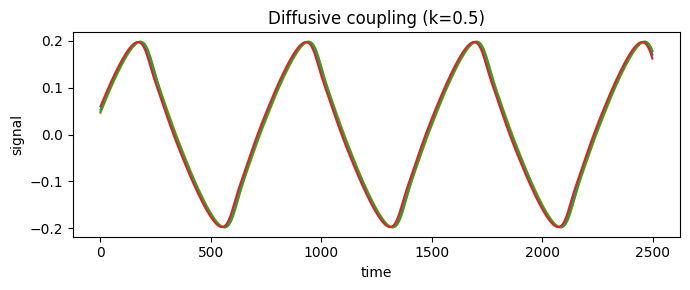

In [3]:
sig_diff = run_with('diffusive')
fig, ax = plt.subplots(figsize=(7, 3))
brainmass.viz.plot_timeseries(sig_diff[:, :4], ax=ax)
ax.set_title("Diffusive coupling (k=0.5)")
fig.tight_layout(); plt.show()

### Additive

Additive coupling sums neighbour inputs directly ($\sum_j W_{ij} x_j$, no
self-term) — simpler, and the right choice when the drive is a genuine *input*
rather than a pull toward consensus. It also accepts a constant bias `b`.

### Laplacian

`coupling='laplacian'` expresses diffusive coupling through the graph Laplacian
$L = D - W$. It is mathematically equivalent to diffusive coupling on a symmetric
`W` but lets you reuse a precomputed Laplacian; `brainmass.laplacian_connectivity`
builds normalized variants.


In [4]:
L = brainmass.laplacian_connectivity(W, normalize=None)
print("Laplacian row sums (~0):", float(jnp.abs(L.sum(axis=1)).max()))
L_sym = brainmass.laplacian_connectivity(W, normalize="sym")   # symmetric-normalized
L_rw = brainmass.laplacian_connectivity(W, normalize="rw")     # random-walk
print("normalized Laplacians:", L_sym.shape, L_rw.shape)

sig_lap = run_with('laplacian')
print("laplacian network ran:", sig_lap.shape)

Laplacian row sums (~0): 4.440892098500626e-16
normalized Laplacians: (8, 8) (8, 8)


/home/chaoming/miniconda3/lib/python3.13/site-packages/jax/_src/numpy/lax_numpy.py:5737: UserWarning: Explicitly requested dtype float64 requested in eye is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  output = _eye(N, M=M, k=k, dtype=dtype)


laplacian network ran: (2500, 8)


## Nonlinear couplings

Nonlinear couplings **saturate** the transmitted signal, which keeps a strongly
coupled network from blowing up and better matches the bounded firing rates of
real neural populations.

### Hyperbolic tangent (`tanh`) — symmetric saturation

`HyperbolicTangentCoupling` applies `tanh` *after* the network sum, so the
coupling current saturates smoothly to $\pm k$. Use it when you want a symmetric,
bounded version of additive coupling. Tune `scale` (steepness) and `k` (the
saturation level).


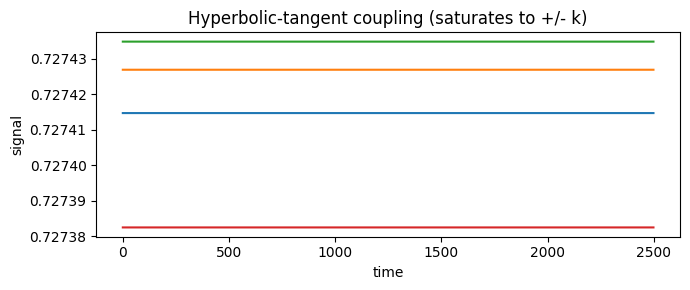

In [5]:
# Network uses the coupling's defaults (tanh: k forwarded, scale=2.0); for full
# control over `scale` build the coupling directly (see "Direct construction").
sig_tanh = run_with('tanh', k=0.5)
fig, ax = plt.subplots(figsize=(7, 3))
brainmass.viz.plot_timeseries(sig_tanh[:, :4], ax=ax)
ax.set_title("Hyperbolic-tangent coupling (saturates to +/- k)")
fig.tight_layout(); plt.show()

### Sigmoidal — asymmetric (firing-rate) saturation

`SigmoidalCoupling` applies a logistic $\sigma$ after the sum, mapping the input
to a bounded, *one-sided* range — the shape of a population firing-rate transfer
function. `slope` controls steepness, `midpoint` the threshold, `a`/`b` an
affine pre-scaling. At zero input the current is $k\,\sigma(-\mathrm{slope}\cdot
\mathrm{midpoint})$.


sigmoidal network ran: (2500, 8)


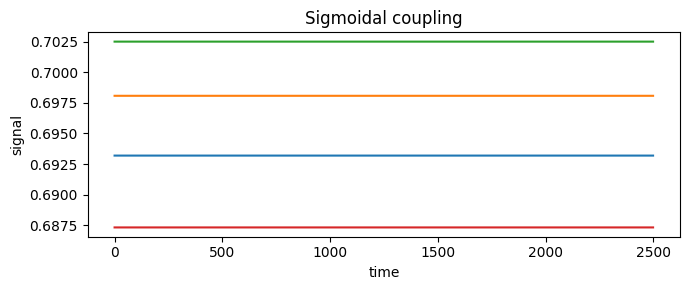

In [6]:
sig_sig = run_with('sigmoidal', k=0.5)   # defaults slope=1, midpoint=0
print("sigmoidal network ran:", sig_sig.shape)
fig, ax = plt.subplots(figsize=(7, 3))
brainmass.viz.plot_timeseries(sig_sig[:, :4], ax=ax)
ax.set_title("Sigmoidal coupling")
fig.tight_layout(); plt.show()

### Sigmoidal Jansen-Rit — pre-nonlinearity transfer

`SigmoidalJansenRitCoupling` is a **pre**-nonlinearity: the sigmoid
$\sigma_{JR}$ is applied to *each source* before the weighted sum, modelling the
presynaptic potential-to-rate transfer in the Jansen-Rit column. It is the
coupling to use for Jansen-Rit whole-brain networks, where the source is the
pyramidal input `y1 - y2`. Parameters `cmin`/`cmax` bound the rate, `midpoint`/`r`
shape the curve.


In [7]:
# Demonstrate the kernel directly on a synthetic source (pre-nonlinearity form).
src = jnp.linspace(0.0, 12.0, N)                  # presynaptic potentials
W_jr = jnp.asarray(W)
c = brainmass.sigmoidal_jansen_rit_coupling(
    src[None, :] * jnp.ones((N, N)),              # each target reads every source
    conn=W_jr, k=1.0, cmin=0.0, cmax=0.005, midpoint=6.0, r=0.56,
)
print("sigmoidal_jansen_rit output:", c.shape, " (bounded firing-rate currents)")
print("range:", float(c.min()), "->", float(c.max()))

sigmoidal_jansen_rit output: (8,)  (bounded firing-rate currents)
range: 0.004580279812216759 -> 0.01149471290409565


When wiring it into a Jansen-Rit `Network`, select it with
`coupling='sigmoidal_jansen_rit'` and `coupled_var='y1'` (or whatever pyramidal
observable your node exposes) — the `Network` plugs the delayed source read into
the coupling exactly as above.


## Choosing a coupling

- **`diffusive`** — default for brain networks; models synchronization. Start here.
- **`additive`** — when the connectome is a genuine input current, not a
  consensus pull. Cheapest.
- **`laplacian`** — diffusive coupling via a (possibly normalized) graph
  Laplacian; reuse a precomputed `L`.
- **`tanh`** — when strong coupling would otherwise destabilize the network and you
  want a symmetric bound.
- **`sigmoidal`** — when the coupling should act like a population firing-rate
  (bounded, one-sided, thresholded).
- **`sigmoidal_jansen_rit`** — the canonical Jansen-Rit pre-synaptic transfer.

Tuning `k`:

1. Start around `k ~ 0.1`–`0.5`.
2. Increase until the network shows the connectivity / synchrony you expect.
3. Too high → everything synchronizes (unphysical); too low → no functional
   connectivity. Sweep it (see {doc}`/howto/parameter_sweeps`).


## Direct construction (advanced)

`Network` is the convenient path, but you can build a coupling object directly
from *prefetch* references to a node's state — useful for custom wiring (e.g.
coupling two different state variables, or asymmetric forward/backward weights).
A diffusive coupling needs a delayed `(N, N)` source read (each target reads every
source) plus a `(N,)` self read.


In [8]:
from brainmass import delay_index
nodes = brainmass.HopfStep(in_size=N, a=0.2, w=0.3)

delays = jnp.ones((N, N)) * (1.0 * u.ms)
idx = delay_index(N)                                    # standard (N, N) source index
x_src = nodes.prefetch_delay('x', (delays, idx),
                             init=braintools.init.Constant(0.0))   # (N, N)
x_self = nodes.prefetch('x')                            # (N,)

coupling = brainmass.DiffusiveCoupling(x_src, x_self, conn=W, k=0.5)
brainstate.nn.init_all_states(nodes)
brainstate.nn.init_all_states(coupling)
with brainstate.environ.context(i=0, t=0. * u.ms):
    current = coupling.update()                          # (N,) per-node current
print("manual diffusive current:", current.shape)

manual diffusive current: (8,)


The nonlinear classes (`SigmoidalCoupling`, `HyperbolicTangentCoupling`,
`SigmoidalJansenRitCoupling`) construct the same way — pass the prefetched source,
`conn`, and the shape parameters. Any of these parameters can be a trainable
`Param` for fitting (see {doc}`/tutorials/06_fitting_with_gradients`).

## Troubleshooting

- **Network explodes** → lower `k`, normalize `W` (divide by row sums or max), or
  switch to a saturating (`tanh` / `sigmoidal`) coupling.
- **No synchronization** → raise `k`; check for isolated nodes in `W`; run longer.
- **Shape error from a coupling** → diffusive coupling needs a `(N, N)` *source*
  read (via `prefetch_delay`) and a `(N,)` *self* read; a plain `prefetch('x')`
  for the source is too small.

## Next steps

- {doc}`/tutorials/04_building_a_network` — full network construction.
- {doc}`/howto/parameter_sweeps` — sweep the coupling strength `k`.
- {doc}`/howto/analyze_results` — measure the FC the coupling produces.
- {doc}`/reference/coupling` — the coupling API reference.
